In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load feature dataset
df = pd.read_csv('../data/features_dataset.csv', parse_dates=['date'])
print(f"Shape: {df.shape}")
print(f"Range: {df['date'].min()} to {df['date'].max()}")
print(f"\nTarget stats:")
print(df['target'].describe())

Shape: (61, 41)
Range: 2020-11-01 00:00:00 to 2025-11-01 00:00:00

Target stats:
count    61.000000
mean     21.105902
std       7.577410
min      10.260000
25%      13.440000
50%      21.770000
75%      26.930000
max      35.670000
Name: target, dtype: float64


In [2]:
# ============================================================
# TRAIN/TEST SPLIT (Time Series - NO random split)
# ============================================================

#Last 12 months as test set
split_date = df['date'].max() - pd.DateOffset(months=12)

train = df[df['date'] <= split_date].copy()
test = df[df['date'] > split_date].copy()

print(f"Train: {len(train)} rows ({train['date'].min()} to {train['date'].max()})")
print(f"Test:  {len(test)} rows ({test['date'].min()} to {test['date'].max()})")

# Defined features (exclude date, targets, and categorical)
exclude_cols = ['date', 'target', 'target_direction', 'rate_regime']
feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in ['float64', 'int64', 'int32']]
print(f"\nFeatures ({len(feature_cols)}):")
print(feature_cols)

X_train = train[feature_cols]
y_train = train['target']
X_test = test[feature_cols]
y_test = test['target']

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Train: 49 rows (2020-11-01 00:00:00 to 2024-11-01 00:00:00)
Test:  12 rows (2024-12-01 00:00:00 to 2025-11-01 00:00:00)

Features (37):
['tbill_91', 'tbill_182', 'tbill_364', 'policy_rate', 'us_tbill_3m', 'fed_funds', 'usd_ghs', 'inflation', 'gdp', 'rate_lag_1', 'rate_lag_2', 'rate_lag_3', 'rate_lag_4', 'momentum_1m', 'momentum_3m', 'momentum_6m', 'roc_1m', 'roc_3m', 'acceleration', 'rolling_mean_6m', 'rolling_mean_12m', 'rolling_std_6m', 'rolling_std_12m', 'z_score_12m', 'yield_slope', 'yield_curvature', 'spread_182_91', 'spread_364_182', 'policy_spread', 'real_rate', 'rate_differential', 'fx_change_1m', 'fx_change_3m', 'inflation_change', 'fed_change', 'high_vol_regime', 'policy_tight']

X_train: (49, 37), y_train: (49,)
X_test: (12, 37), y_test: (12,)


In [3]:
# ============================================================
# EVALUATION FUNCTIONS
# ============================================================

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model(y_true, y_pred, model_name):
    """Calculate regression and directional accuracy metrics"""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Directional accuracy: did it correctly predict up/down?
    actual_direction = np.diff(np.concatenate([[y_true.iloc[0]], y_true.values])) > 0
    pred_direction = np.diff(np.concatenate([[y_true.iloc[0]], y_pred])) > 0
    dir_accuracy = np.mean(actual_direction == pred_direction) * 100
    
    print(f"\n{'='*40}")
    print(f"Model: {model_name}")
    print(f"{'='*40}")
    print(f"RMSE:                {rmse:.4f}")
    print(f"MAE:                 {mae:.4f}")
    print(f"R-squared:           {r2:.4f}")
    print(f"Directional Accuracy: {dir_accuracy:.1f}%")
    
    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'directional_accuracy': dir_accuracy
    }

# Store all results
results = []
predictions = {}

In [4]:
# ============================================================
# MODEL 1: NAIVE BASELINE (previous month's rate = next month's rate)
# ============================================================

y_pred_naive = test['tbill_91'].values  # current rate as prediction
result = evaluate_model(y_test, y_pred_naive, 'Naive Baseline')
results.append(result)
predictions['Naive Baseline'] = y_pred_naive


Model: Naive Baseline
RMSE:                3.0717
MAE:                 1.6308
R-squared:           0.7307
Directional Accuracy: 83.3%


In [5]:
# ============================================================
# MODEL 2: ARIMA
# ============================================================

from statsmodels.tsa.arima.model import ARIMA

# Only the T-bill rate series for ARIMA
train_series = train.set_index('date')['tbill_91']

# Fit ARIMA - try (1,1,1) as starting point
model_arima = ARIMA(train_series, order=(1, 1, 1))
fitted_arima = model_arima.fit()
print(fitted_arima.summary())

# Forecast
forecast_arima = fitted_arima.forecast(steps=len(test))
y_pred_arima = forecast_arima.values

result = evaluate_model(y_test, y_pred_arima, 'ARIMA(1,1,1)')
results.append(result)
predictions['ARIMA(1,1,1)'] = y_pred_arima

                               SARIMAX Results                                
Dep. Variable:               tbill_91   No. Observations:                   49
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -111.033
Date:                Mon, 22 Jun 2026   AIC                            228.065
Time:                        14:33:13   BIC                            233.679
Sample:                    11-01-2020   HQIC                           230.187
                         - 11-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3615      0.940      0.384      0.701      -1.482       2.205
ma.L1         -0.1410      0.956     -0.148      0.883      -2.014       1.732
sigma2         5.9734      0.337     17.712      0.0

C:\Users\user\Desktop\GH-Yield\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Desktop\GH-Yield\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Desktop\GH-Yield\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [6]:
# ============================================================
# MODEL 3: SARIMA (with seasonality)
# ============================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA with seasonal period of 12 months
model_sarima = SARIMAX(train_series, order=(1, 1, 1), seasonal_order=(1, 0, 1, 12))
fitted_sarima = model_sarima.fit(disp=False)

forecast_sarima = fitted_sarima.forecast(steps=len(test))
y_pred_sarima = forecast_sarima.values

result = evaluate_model(y_test, y_pred_sarima, 'SARIMA(1,1,1)(1,0,1,12)')
results.append(result)
predictions['SARIMA'] = y_pred_sarima

C:\Users\user\Desktop\GH-Yield\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Desktop\GH-Yield\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Model: SARIMA(1,1,1)(1,0,1,12)
RMSE:                13.2906
MAE:                 12.0752
R-squared:           -4.0413
Directional Accuracy: 50.0%


C:\Users\user\Desktop\GH-Yield\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [7]:
# ============================================================
# MODEL 4: SARIMAX (SARIMA with external regressors)
# ============================================================

# Use macro features as exogenous variables
exog_cols = ['policy_rate', 'us_tbill_3m', 'usd_ghs', 'inflation']
exog_train = train.set_index('date')[exog_cols]
exog_test = test.set_index('date')[exog_cols]

model_sarimax = SARIMAX(
    train_series, 
    exog=exog_train,
    order=(1, 1, 1), 
    seasonal_order=(1, 0, 0, 12)
)
fitted_sarimax = model_sarimax.fit(disp=False)

forecast_sarimax = fitted_sarimax.forecast(steps=len(test), exog=exog_test)
y_pred_sarimax = forecast_sarimax.values

result = evaluate_model(y_test, y_pred_sarimax, 'SARIMAX (with macro regressors)')
results.append(result)
predictions['SARIMAX'] = y_pred_sarimax

C:\Users\user\Desktop\GH-Yield\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\user\Desktop\GH-Yield\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Model: SARIMAX (with macro regressors)
RMSE:                18.6353
MAE:                 15.4958
R-squared:           -8.9112
Directional Accuracy: 41.7%


In [8]:
# ============================================================
# MODEL 5: PROPHET
# ============================================================

from prophet import Prophet

# Prophet requires columns named 'ds' and 'y'
prophet_train = train[['date', 'tbill_91']].rename(columns={'date': 'ds', 'tbill_91': 'y'})
prophet_test = test[['date']].rename(columns={'date': 'ds'})

# Add regressors
for col in ['policy_rate', 'us_tbill_3m', 'usd_ghs', 'inflation']:
    prophet_train[col] = train[col].values
    prophet_test[col] = test[col].values

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

# Add external regressors
for col in ['policy_rate', 'us_tbill_3m', 'usd_ghs', 'inflation']:
    model_prophet.add_regressor(col)

model_prophet.fit(prophet_train)
forecast_prophet = model_prophet.predict(prophet_test)
y_pred_prophet = forecast_prophet['yhat'].values

result = evaluate_model(y_test, y_pred_prophet, 'Prophet (with regressors)')
results.append(result)
predictions['Prophet'] = y_pred_prophet

Importing plotly failed. Interactive plots will not work.
14:33:15 - cmdstanpy - INFO - Chain [1] start processing
14:33:15 - cmdstanpy - INFO - Chain [1] done processing



Model: Prophet (with regressors)
RMSE:                6.3660
MAE:                 5.0755
R-squared:           -0.1566
Directional Accuracy: 66.7%


In [9]:
# ============================================================
# MODEL 6: XGBOOST
# ============================================================

from xgboost import XGBRegressor

model_xgb = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

result = evaluate_model(y_test, y_pred_xgb, 'XGBoost')
results.append(result)
predictions['XGBoost'] = y_pred_xgb

# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 features (XGBoost):")
print(importance.head(10))


Model: XGBoost
RMSE:                3.8054
MAE:                 3.1307
R-squared:           0.5867
Directional Accuracy: 83.3%

Top 10 features (XGBoost):
              feature  importance
30  rate_differential    0.425633
0            tbill_91    0.095306
2           tbill_364    0.064637
17             roc_3m    0.055419
15        momentum_6m    0.050395
20   rolling_mean_12m    0.048431
1           tbill_182    0.046733
22    rolling_std_12m    0.044544
11         rate_lag_3    0.038061
23        z_score_12m    0.033390


In [10]:
# ============================================================
# MODEL 7: LIGHTGBM
# ============================================================

from lightgbm import LGBMRegressor

model_lgb = LGBMRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

model_lgb.fit(X_train, y_train)
y_pred_lgb = model_lgb.predict(X_test)

result = evaluate_model(y_test, y_pred_lgb, 'LightGBM')
results.append(result)
predictions['LightGBM'] = y_pred_lgb


Model: LightGBM
RMSE:                6.6134
MAE:                 5.9502
R-squared:           -0.2483
Directional Accuracy: 66.7%


In [11]:
# ============================================================
# MODEL 8: ENSEMBLE (Weighted Average)
# ============================================================

# Simple average of top models
y_pred_ensemble = (y_pred_xgb + y_pred_lgb + y_pred_sarimax) / 3

result = evaluate_model(y_test, y_pred_ensemble, 'Ensemble (XGB + LGB + SARIMAX)')
results.append(result)
predictions['Ensemble'] = y_pred_ensemble


Model: Ensemble (XGB + LGB + SARIMAX)
RMSE:                9.3168
MAE:                 8.0685
R-squared:           -1.4774
Directional Accuracy: 66.7%


In [12]:
# ============================================================
# MODEL COMPARISON TABLE
# ============================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('rmse')
print("\n" + "="*70)
print("MODEL COMPARISON (sorted by RMSE)")
print("="*70)
print(results_df.to_string(index=False))

# Save results
results_df.to_csv('../data/model_comparison.csv', index=False)


MODEL COMPARISON (sorted by RMSE)
                          model      rmse       mae        r2  directional_accuracy
                 Naive Baseline  3.071697  1.630833  0.730715             83.333333
                        XGBoost  3.805391  3.130711  0.586711             83.333333
      Prophet (with regressors)  6.365956  5.075538 -0.156598             66.666667
                       LightGBM  6.613443  5.950194 -0.248275             66.666667
 Ensemble (XGB + LGB + SARIMAX)  9.316848  8.068546 -1.477384             66.666667
        SARIMA(1,1,1)(1,0,1,12) 13.290584 12.075219 -4.041309             50.000000
                   ARIMA(1,1,1) 13.307239 12.102620 -4.053952             41.666667
SARIMAX (with macro regressors) 18.635300 15.495823 -8.911241             41.666667


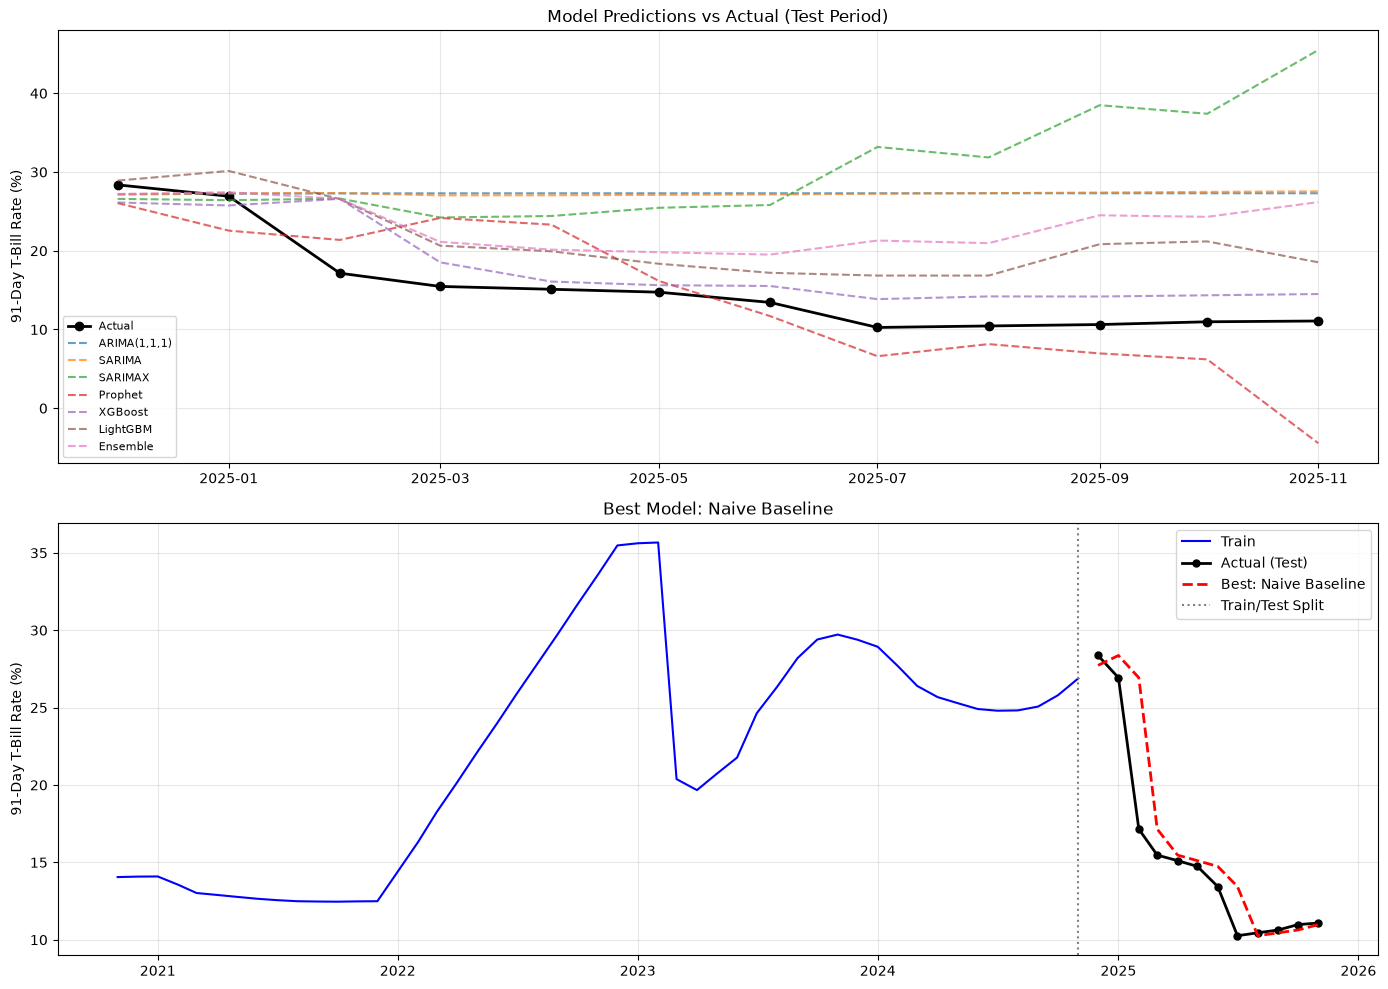

Chart saved!


In [13]:
# ============================================================
# FORECAST VISUALIZATION
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: All model predictions vs actual
axes[0].plot(test['date'], y_test, 'ko-', linewidth=2, markersize=6, label='Actual')
for name, preds in predictions.items():
    if name != 'Naive Baseline':
        axes[0].plot(test['date'], preds, '--', linewidth=1.5, alpha=0.7, label=name)

axes[0].set_title('Model Predictions vs Actual (Test Period)')
axes[0].set_ylabel('91-Day T-Bill Rate (%)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2: Full history + best model forecast
best_model = results_df.iloc[0]['model']
axes[1].plot(train['date'], train['tbill_91'], 'b-', linewidth=1.5, label='Train')
axes[1].plot(test['date'], y_test, 'ko-', linewidth=2, markersize=5, label='Actual (Test)')
axes[1].plot(test['date'], predictions[best_model], 'r--', linewidth=2, label=f'Best: {best_model}')
axes[1].axvline(x=split_date, color='gray', linestyle=':', label='Train/Test Split')
axes[1].set_title(f'Best Model: {best_model}')
axes[1].set_ylabel('91-Day T-Bill Rate (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/model_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [14]:
# ============================================================
# WALK-FORWARD CROSS-VALIDATION (Best Model)
# ============================================================

from sklearn.model_selection import TimeSeriesSplit

# Use XGBoost for walk-forward CV (adjust if another model won)
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []

X_all = df[feature_cols].dropna()
y_all = df.loc[X_all.index, 'target']

# Drop any remaining NaN
mask = ~(X_all.isna().any(axis=1) | y_all.isna())
X_all = X_all[mask]
y_all = y_all[mask]

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_all)):
    X_tr, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_all.iloc[train_idx], y_all.iloc[val_idx]
    
    model = XGBRegressor(
        n_estimators=100, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    )
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    mae = mean_absolute_error(y_val, y_pred)
    cv_scores.append({'fold': fold+1, 'rmse': rmse, 'mae': mae, 'train_size': len(X_tr), 'val_size': len(X_val)})
    print(f"Fold {fold+1}: RMSE={rmse:.4f}, MAE={mae:.4f} (Train: {len(X_tr)}, Val: {len(X_val)})")

cv_df = pd.DataFrame(cv_scores)
print(f"\nMean RMSE: {cv_df['rmse'].mean():.4f} (+/- {cv_df['rmse'].std():.4f})")
print(f"Mean MAE:  {cv_df['mae'].mean():.4f} (+/- {cv_df['mae'].std():.4f})")

Fold 1: RMSE=7.4892, MAE=5.8351 (Train: 11, Val: 10)
Fold 2: RMSE=5.5388, MAE=4.7281 (Train: 21, Val: 10)
Fold 3: RMSE=6.0377, MAE=5.6645 (Train: 31, Val: 10)
Fold 4: RMSE=1.7009, MAE=1.3969 (Train: 41, Val: 10)
Fold 5: RMSE=4.2600, MAE=3.6394 (Train: 51, Val: 10)

Mean RMSE: 5.0053 (+/- 2.1791)
Mean MAE:  4.2528 (+/- 1.8204)


In [15]:
# ============================================================
# MLFLOW EXPERIMENT TRACKING
# ============================================================

import mlflow

# Set experiment
mlflow.set_experiment("GH-Yield-TBill-Forecasting")

# Log each model
for _, row in results_df.iterrows():
    with mlflow.start_run(run_name=row['model']):
        mlflow.log_metric("rmse", row['rmse'])
        mlflow.log_metric("mae", row['mae'])
        mlflow.log_metric("r2", row['r2'])
        mlflow.log_metric("directional_accuracy", row['directional_accuracy'])
        mlflow.log_param("model_name", row['model'])
        mlflow.log_param("train_size", len(train))
        mlflow.log_param("test_size", len(test))
        mlflow.log_param("n_features", len(feature_cols))

print("All models logged to MLflow!")
print(f"View dashboard: run 'mlflow ui' in terminal")

# Save final summary
print(f"\n{'='*60}")
print("WEEK 2 MODELING COMPLETE")
print(f"{'='*60}")
print(f"Models trained: {len(results_df)}")
print(f"Best model: {results_df.iloc[0]['model']}")
print(f"Best RMSE: {results_df.iloc[0]['rmse']:.4f}")
print(f"Best Directional Accuracy: {results_df.iloc[0]['directional_accuracy']:.1f}%")
print(f"Walk-forward CV Mean RMSE: {cv_df['rmse'].mean():.4f}")

2026/06/22 14:33:23 INFO mlflow.tracking.fluent: Experiment with name 'GH-Yield-TBill-Forecasting' does not exist. Creating a new experiment.


All models logged to MLflow!
View dashboard: run 'mlflow ui' in terminal

WEEK 2 MODELING COMPLETE
Models trained: 8
Best model: Naive Baseline
Best RMSE: 3.0717
Best Directional Accuracy: 83.3%
Walk-forward CV Mean RMSE: 5.0053
